In [1]:
import os
import sys
current_directory = os.getcwd()
upper_directory = os.path.abspath(os.path.join(current_directory, ".."))
sys.path.append(upper_directory)


## ================================================================= ##

import numpy as np
import cvxpy as cp
from cvxpy import quad_form
import numpy as np
import time 
import tqdm

import matplotlib.pyplot as plt

from sklearn.gaussian_process.kernels import RBF
from sklearn.decomposition import KernelPCA
from scipy.linalg import khatri_rao

# Set the random seed
np.random.seed(2025)

In [2]:
# Load data
data_save_path = '../data/L96_data_dim40'
N = 30 # Increase this to use more training data. More accuracte but risk of OOM.
train_idx = np.random.choice(500, N, replace=False)
train_seq_state = np.load(data_save_path + '/train_seq_state.npy', mmap_mode='r')[train_idx, 500:, ...]
train_seq_obs = np.load(data_save_path + '/train_seq_obs.npy', mmap_mode='r')[train_idx, 500:, ...]
train_seq_hist = np.load(data_save_path + '/train_seq_hist.npy', mmap_mode='r')[train_idx, 500:, ...]

### $C_{S^+|S}$

In [3]:
N, T,_ = train_seq_state.shape
print("[INFO] Number of samples: ", N*T)

[INFO] Number of samples:  45000


In [4]:
# state_feature_transform = KernelPCA(n_components=80, kernel='matern2.5', fit_inverse_transform=True)
d_s = 80 # Number of features 

state_feature_transform = KernelPCA(n_components=d_s, kernel='rbf', fit_inverse_transform=True)
X = np.array([train_seq_state[i,j] for i in range(N) for j in range(0,T-1)])
X_next = np.array([train_seq_state[i,j] for i in range(N) for j in range(1,T)])

state_mean = np.mean(X, axis=0)
state_std = np.std(X, axis=0)

X = (X - state_mean) / state_std
X_next = (X_next - state_mean) / state_std

X_features = state_feature_transform.fit_transform(X=X)
X_next_features = state_feature_transform.transform(X_next)

In [5]:
K_X = X_features.T@X_features
K_X_regularized = K_X + 1e-3 * np.eye(K_X.shape[0])
K_X_INV = np.linalg.solve(K_X_regularized, X_next_features.T)
C_fwd = K_X_INV @ X_features 

#### B and Q

In [6]:
B = np.cov(X_features, rowvar=False)
B = np.linalg.pinv(B+1e-3*np.eye(B.shape[0]))
B = (B + B.T) / 2

fwd_error = X_next_features - (C_fwd @ X_features.T).T
Q = np.cov(fwd_error, rowvar=False)
Q = np.linalg.pinv(Q+1e-3*np.eye(Q.shape[0]))
Q = (Q + Q.T) / 2

### $C_{S|OH}$

In [7]:
obs_feature_transform = KernelPCA(n_components=32, kernel='rbf')
hist_feature_transform = KernelPCA(n_components=32, kernel='rbf')

O = np.array([train_seq_obs[i,j] for i in range(N) for j in range(0,T-1)])
H = np.array([train_seq_hist[i,j].flatten() for i in range(N) for j in range(0,T-1)])

In [8]:
obs_mean = np.mean(O, axis=0)
obs_std = np.std(O, axis=0)

O = (O - obs_mean) / obs_std
O_features = obs_feature_transform.fit_transform(X=O)

In [9]:
hist_mean = np.mean(H, axis=0)
hist_std = np.std(H, axis=0)

H = (H - hist_mean) / hist_std
H_features = hist_feature_transform.fit_transform(X=H)

In [10]:
OH = khatri_rao(O_features.T, H_features.T).T

In [11]:
K_OH = OH@OH.T
K_OH_regularized = K_OH + 1e-3 * np.eye(K_OH.shape[0])
K_OH_INV = np.linalg.solve(K_OH_regularized, X_features)
C_Inv = K_OH_INV.T @ OH

#### R

In [12]:
obs_error = X_features - (C_Inv @ OH.T).T
R = np.cov(obs_error, rowvar=False)
R = np.linalg.pinv(R + 1e-3*np.eye(R.shape[0]))

# Symmetrize R
R = (R + R.T) / 2

### Forward model

In [13]:
class phi_S:
    def __init__(self, state_feature_transform, state_mean, state_std) -> None:
        self.state_feature_transform = state_feature_transform
        self.state_mean = state_mean
        self.state_std = state_std
        self.hidden_dims = [state_feature_transform.n_components]
        
    def __call__(self, x):
        try:
            x_feature = self.state_feature_transform.transform((x - self.state_mean) / self.state_std)
        except:
            x = x[None,:]
            x_feature = self.state_feature_transform.transform((x - self.state_mean) / self.state_std)
        return x_feature

class phi_inv_S:
    def __init__(self, state_feature_transform, state_mean, state_std) -> None:
        self.state_feature_transform = state_feature_transform
        self.state_mean = state_mean
        self.state_std = state_std
        self.hidden_dim = [state_feature_transform.n_components]
        
    def __call__(self, z):
        try:
            x = self.state_feature_transform.inverse_transform(z) * self.state_std + self.state_mean
        except:
            z = z[None,:]
            x = self.state_feature_transform.inverse_transform(z) * self.state_std + self.state_mean
        return x


class forward_model:
    def __init__(self, C_fwd, phi_S, phi_inv_S) -> None:
        self.state_feature_transform = state_feature_transform
        self.C_fwd = C_fwd
        self.phi_S = phi_S
        self.phi_inv_S = phi_inv_S
    
    def __call__(self, x):
        x_feature = self.phi_S(x)
        return (self.C_forward @ x_feature.T).T
    
# state_mean = np.mean(train_seq_state, axis=(0,1))
# state_std = np.std(train_seq_state, axis=(0,1))

fwd_model = forward_model(C_fwd, 
                          phi_S(state_feature_transform, state_mean, state_std), 
                          phi_inv_S(state_feature_transform, state_mean, state_std))

### Inv Obs Model

In [14]:
class inverse_model:
    def __init__(self, C_Inv, phi_S, phi_inv_S, 
                 obs_feature_transform, obs_mean, obs_std,
                 hist_feature_transform, hist_mean, hist_std) -> None:
        self.obs_feature_transform = obs_feature_transform
        self.hist_feature_transform = hist_feature_transform
        self.C_Inv = C_Inv
        self.phi_S = phi_S
        self.phi_inv_S = phi_inv_S
        self.obs_mean = obs_mean
        self.obs_std = obs_std
        self.hist_mean = hist_mean
        self.hist_std = hist_std
    
    def __call__(self, o, h):
        o_feature = self.obs_feature_transform.transform((o - self.obs_mean) / self.obs_std)
        h_feature = self.hist_feature_transform.transform((h - self.hist_mean) / self.hist_std)
        oh_feature = khatri_rao(o_feature.T, h_feature.T).T
        x_feature = (self.C_Inv @ oh_feature.T).T
        return x_feature


# obs_mean = np.mean(train_seq_obs, axis=(0,1))
# obs_std = np.std(train_seq_obs, axis=(0,1))

# hist_mean = np.mean(train_seq_hist, axis=(0,1)).flatten()
# hist_std = np.std(train_seq_hist, axis=(0,1)).flatten()

inv_obs_model = inverse_model(C_Inv, 
                              phi_S(state_feature_transform, state_mean, state_std), 
                              phi_inv_S(state_feature_transform, state_mean, state_std),
                              obs_feature_transform, obs_mean, obs_std,
                              hist_feature_transform, hist_mean, hist_std)

### Define 4D-Var Solver

In [15]:
def QP_solver(z_b, seq_z, F, B, R, Q, T):
    """
    Quadratic Programming Solver
    """
    constraints = []
    state_dim = z_b.shape[0]
    pred_seq_z = cp.Variable((T, state_dim))
    cost = 0 
    
    penalty = np.linspace(0.1, 1, T-1)[::-1]
    for t in range(T):
        if t == 0:
            cost += quad_form(pred_seq_z[t] - z_b, B)
            cost += quad_form(pred_seq_z[t] - seq_z[t], R)
            
        else:   
            cost += quad_form(pred_seq_z[t] - seq_z[t], R)
            cost += quad_form(pred_seq_z[t] - F@pred_seq_z[t-1], penalty[t-1]*Q)
    objective = cp.Minimize(cost)
    prob = cp.Problem(objective, constraints)
    prob.solve() 
    # Get the final solution
    analyzed_traj_states = pred_seq_z.value
    
    return analyzed_traj_states

class Tensor_Var:
    def __init__(self, forward_model, observation_model, n_state, n_obs, B, R, Q) -> None:
        self.forward_model = forward_model
        self.observation_model = observation_model
        self.n_state = n_state
        self.n_obs = n_obs
        self.n_hidden = self.forward_model.phi_S.hidden_dims[-1]

        self.B = B
        self.R = R
        self.Q = Q
        
    def perform_4DVar(self, 
                           seq_obs:np.array, 
                           seq_hist:np.array,
                           x_b:np.array=None, 
                           assimilation_window:int=3, 
                           T:int=500):
        
        B = self.B
        R = self.R
        Q = self.Q

        F = self.forward_model.C_fwd
        if x_b is None:
            x_b = np.random.normal(0, 1, self.n_state)
        
        z_b = self.forward_model.phi_S(x_b)[0]
        print(z_b.shape)

        horizon_traj_estimation = []
        start_time = time.time()
        for start in tqdm.tqdm(range(0, T, assimilation_window)):
            end = min(start + assimilation_window, T)
            # project the phi_o, phi_h to phi_s
            hist = seq_hist[start:end]
            hist = hist.reshape(hist.shape[0], -1)
            obs = seq_obs[start:end]
            seq_z = self.observation_model(obs, hist)

            result = QP_solver(z_b=z_b, 
                                seq_z=seq_z, 
                                F=F, 
                                B=B, 
                                Q=Q, 
                                R=R, 
                                T=assimilation_window)

            optimal_traj = self.forward_model.phi_inv_S(result)
            horizon_traj_estimation.extend(optimal_traj)
        end_time = time.time()
        evaluation_time = end_time - start_time
        return horizon_traj_estimation, evaluation_time

### Perform DA

In [16]:
del train_seq_hist
del train_seq_obs
del train_seq_state

In [17]:
# Set the parameters
n_state = 40
n_obs = int(n_state * 0.2)

ass_w = 5 # assimilation window 
ass_T = ass_w * 20

num_mc = 10 # number of repeated experiments

In [18]:
DA_Tensor_Var = Tensor_Var(fwd_model, 
                           inv_obs_model, 
                           n_state=n_state,
                           n_obs=n_obs,
                           B=B,
                           R=R, 
                           Q=Q
                          )

In [19]:
# Load data
data_save_path = '../data/L96_data_dim40'
test_seq_state = np.load(data_save_path + '/test_seq_state.npy', mmap_mode='r')[:num_mc, 500:, ...]
test_seq_obs = np.load(data_save_path + '/test_seq_obs.npy', mmap_mode='r')[:num_mc, 500:, ...]
test_seq_hist = np.load(data_save_path + '/test_seq_hist.npy', mmap_mode='r')[:num_mc, 500:, ...]
x_b = np.mean(test_seq_state, axis=(0,1))

[INFO] Assimilation Window Length: 5
[INFO] Traj Length: 100


DA Evaulation:   0%|          | 0/10 [00:00<?, ?it/s]

(80,)


DA Evaulation:  10%|█         | 1/10 [00:02<00:20,  2.26s/it]

[INFO] 0th traj Estimation Error: 0.11605942657571144
(80,)


...

[INFO] 7th traj Estimation Error: 0.12480258689374775
(80,)


DA Evaulation:  90%|█████████ | 9/10 [00:20<00:02,  2.28s/it]

[INFO] 8th traj Estimation Error: 0.11707490024085114
(80,)


DA Evaulation: 100%|██████████| 10/10 [00:22<00:00,  2.25s/it]


[INFO] 9th traj Estimation Error: 0.10816736793324397


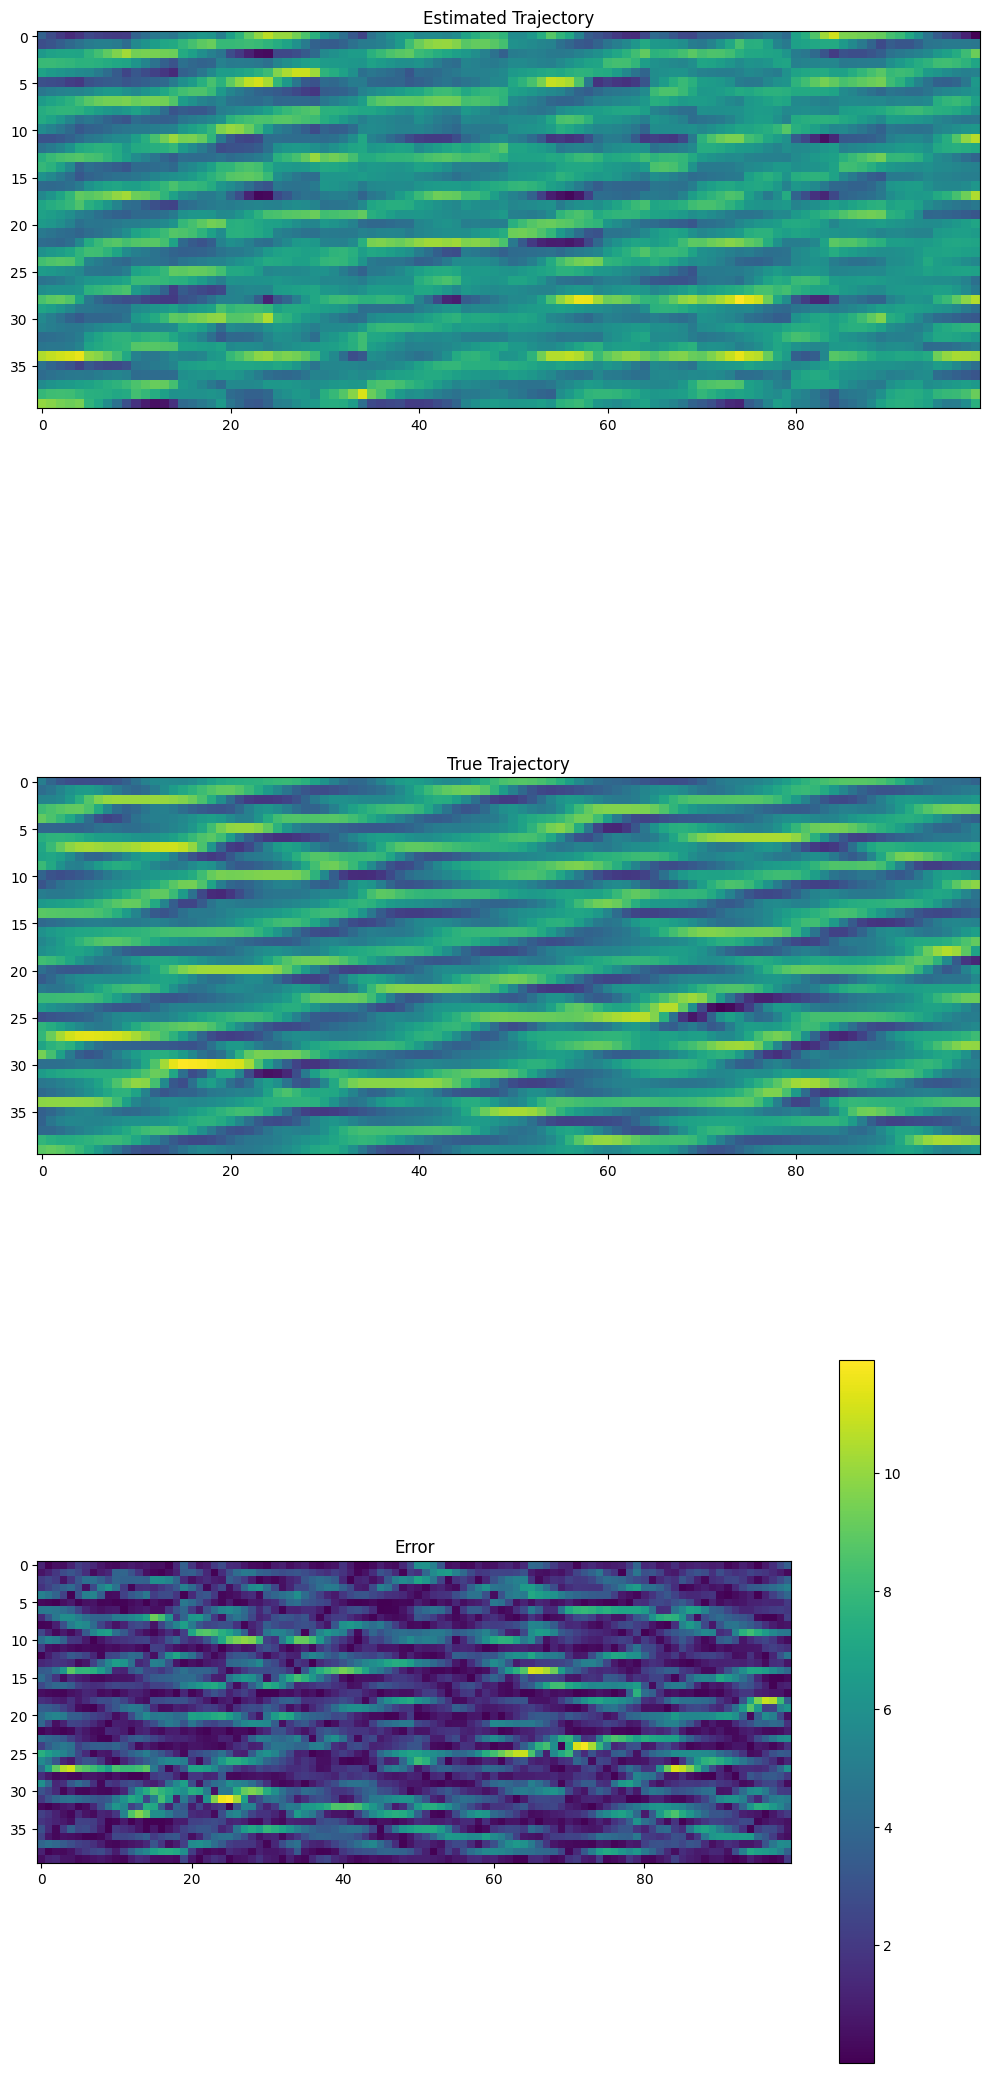

In [21]:
error_list = np.zeros(num_mc)
time_list = np.zeros(num_mc)
max_value = test_seq_state.max()
min_value = test_seq_state.min()
print("[INFO] Assimilation Window Length: {}".format(ass_w))
print("[INFO] Traj Length: {}".format(ass_T))
for i in tqdm.tqdm(range(num_mc), desc="DA Evaulation"):
    traj_true = test_seq_state[i, :ass_T]
    traj_estimation, eval_time = DA_Tensor_Var.perform_4DVar(test_seq_obs[i], 
                                                             seq_hist=test_seq_hist[i], 
                                                             x_b=x_b, 
                                                             assimilation_window=ass_w, 
                                                             T=ass_T)
    rmse = np.sqrt( np.mean( (np.array(traj_estimation) - traj_true)**2) )/(max_value-min_value)
    error_list[i] = rmse
    time_list[i] = eval_time
    print("[INFO] {}th traj Estimation Error: {}".format(i,rmse))


fig, ax = plt.subplots(3, 1, figsize=(10, 24))
ax[0].imshow(np.array(traj_estimation).T)
ax[0].set_title('Estimated Trajectory')
ax[1].imshow(traj_true.T)
ax[1].set_title('True Trajectory')
cbar = ax[2].imshow(np.abs(np.array(traj_estimation).T - traj_true.T))
plt.colorbar(cbar, ax=ax[2], shrink=0.8)
ax[2].set_title('Error')
plt.tight_layout()
plt.show()